# CIFAR-10 Optimizer Benchmark — Phase-Aware v5 vs Baselines

Direct port of the IMDB dynamics notebook to **CIFAR-10** image classification.

Key changes:
- ResNet-9 (lightweight, ~6.6M params) instead of LSTM — trains fast on Colab T4
- All baselines get a **cosine + linear warmup LR scheduler** for a fair comparison
- Reduced to **3 seeds** and **30 epochs** to finish in ~45 min on free Colab GPU
- Same DynamicsLogger, perturbation robustness, and plot structure as the IMDB notebook

In [ ]:
!pip install torch torchvision numpy matplotlib scipy -q
print("All packages ready.")

All packages ready.


In [ ]:
import os, math, time, json, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim import Optimizer
from datetime import datetime
from scipy import stats
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Using device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB


## CIFAR-10 Data Loader

Downloads CIFAR-10 via torchvision. Uses standard normalization (mean/std from the training set). Heavy augmentation on train: random crop, horizontal flip. No augmentation on val/test — same as standard benchmarks.

In [ ]:
import torchvision
import torchvision.transforms as T

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

def get_cifar10_loaders(batch_size=256, num_workers=2, val_split=0.1, seed=42):
    """Download CIFAR-10, split train into train/val, return loaders."""
    train_tf = T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        T.ToTensor(),
        T.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])
    test_tf = T.Compose([
        T.ToTensor(),
        T.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])
    full_train = torchvision.datasets.CIFAR10(
        root="/content/data", train=True, download=True, transform=train_tf)
    test_ds = torchvision.datasets.CIFAR10(
        root="/content/data", train=False, download=True, transform=test_tf)

    n_val   = int(len(full_train) * val_split)
    n_train = len(full_train) - n_val
    gen = torch.Generator().manual_seed(seed)
    train_sub, val_sub = torch.utils.data.random_split(
        full_train, [n_train, n_val], generator=gen)

    train_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True,
                              drop_last=True)
    val_loader   = DataLoader(val_sub, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    print(f"[data] Train: {n_train:,}  Val: {n_val:,}  Test: {len(test_ds):,}")
    print(f"[data] Batch size: {batch_size}  Steps/epoch: {len(train_loader)}")
    return train_loader, val_loader, test_loader

# Smoke test
_tl, _vl, _tel = get_cifar10_loaders(batch_size=4, num_workers=0)
_imgs, _lbls = next(iter(_tl))
assert _imgs.shape == (4, 3, 32, 32), f"Expected (4,3,32,32), got {_imgs.shape}"
assert _lbls.max() <= 9
print(f"Loader OK — batch {list(_imgs.shape)}, labels {_lbls.tolist()}")
del _tl, _vl, _tel

100%|██████████| 170M/170M [00:11<00:00, 15.3MB/s]


[data] Train: 45,000  Val: 5,000  Test: 10,000
[data] Batch size: 4  Steps/epoch: 11250
Loader OK — batch [4, 3, 32, 32], labels [0, 6, 6, 1]


## Model — ResNet-9

Lightweight ResNet-9 (~6.6M params). Trains to ~93% on CIFAR-10 in ~30 epochs. Fast enough for free Colab GPU without disconnecting.

Architecture: 4 conv blocks with residual shortcuts, global average pooling, 2-layer FC head.

In [ ]:
class ConvBnRelu(nn.Module):
    def __init__(self, in_c, out_c, kernel=3, stride=1, padding=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel, stride=stride,
                      padding=padding, bias=False),
            nn.BatchNorm2d(out_c),
            nn.GELU(),
        )
    def forward(self, x): return self.net(x)


class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.res = nn.Sequential(
            ConvBnRelu(channels, channels),
            ConvBnRelu(channels, channels),
        )
    def forward(self, x): return x + self.res(x)


class ResNet9(nn.Module):
    """ResNet-9: ~6.6M params. ~30 epochs to ~93% on CIFAR-10."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.prep  = ConvBnRelu(3,  64)
        self.layer1 = nn.Sequential(ConvBnRelu(64, 128),
                                    nn.MaxPool2d(2), ResBlock(128))
        self.layer2 = nn.Sequential(ConvBnRelu(128, 256),
                                    nn.MaxPool2d(2))
        self.layer3 = nn.Sequential(ConvBnRelu(256, 512),
                                    nn.MaxPool2d(2), ResBlock(512))
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.drop   = nn.Dropout(0.2)
        self.fc     = nn.Sequential(
            nn.Linear(512, 128), nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes))

    def forward(self, x):
        x = self.prep(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x).flatten(1)
        x = self.drop(x)
        return self.fc(x)


# Sanity check
_m = ResNet9()
_x = torch.zeros(4, 3, 32, 32)
_o = _m(_x)
assert _o.shape == (4, 10)
n_params = sum(p.numel() for p in _m.parameters())
print(f"ResNet9: {n_params/1e6:.2f}M params, output {_o.shape}")
del _m, _x, _o

ResNet9: 6.63M params, output torch.Size([4, 10])


## PhaseAwareOptimizer v5 — Flat-Minima Edition

Exact port from the IMDB notebook. The optimizer is task-agnostic — it operates on gradients only, so it works identically for image classification.

Key features vs vanilla Adam:
1. **Noise floor** — Cauchy noise never decays to zero, maintains flatness pressure
2. **SAM-lite** — single-pass sharpness-aware correction, no extra backward
3. **Decoupled weight decay** (AdamW-style) — biggest generalisation fix
4. **Dynamic phase** using gradient variance + loss plateau detection
5. **β1 sine schedule** — moderate → strong → moderate momentum

In [ ]:
class PhaseAwareOptimizer(Optimizer):
    """
    Phase-Aware Optimizer v5 — Flat-Minima Edition.
    Ported from IMDB notebook (task-agnostic, works on any gradient stream).
    """
    def __init__(self, params,
                 lr_max=0.001, lr_min=2e-5,
                 warmup_ratio=0.03, hold_frac=0.12,
                 beta1=0.9, beta1_max=0.95,
                 beta2=0.999, eps=1e-8,
                 noise_max=0.04, noise_min=0.008,
                 sam_coeff=0.015,
                 weight_decay=0.01,
                 total_steps=10000, max_grad_norm=1.0,
                 phase_type="adaptive",
                 var_window=50, time_weight=0.7):
        defaults = dict(
            lr_max=lr_max, lr_min=lr_min,
            warmup_ratio=warmup_ratio, hold_frac=hold_frac,
            beta1=beta1, beta1_max=beta1_max,
            beta2=beta2, eps=eps,
            noise_max=noise_max, noise_min=noise_min,
            sam_coeff=sam_coeff,
            weight_decay=weight_decay,
            total_steps=total_steps, max_grad_norm=max_grad_norm,
            phase_type=phase_type,
            var_window=var_window, time_weight=time_weight,
        )
        super().__init__(params, defaults)
        self.step_count         = 0
        self.phase              = 0.0
        self.current_lr         = 0.0
        self.current_noise      = 0.0
        self._grad_norm_history = []
        self._initial_var       = None
        self._loss_history      = []

    def _phi_time(self):
        return min(1.0, self.step_count / max(1, self.defaults["total_steps"]))

    def _phi(self, avg_grad_norm):
        phi_t = self._phi_time()
        if self.defaults["phase_type"] == "time":
            return phi_t
        w = self.defaults["var_window"]
        self._grad_norm_history.append(avg_grad_norm)
        if len(self._grad_norm_history) > w * 4:
            self._grad_norm_history = self._grad_norm_history[-w * 2:]
        if len(self._grad_norm_history) < w:
            return phi_t
        recent  = self._grad_norm_history[-w:]
        mean_r  = sum(recent) / w
        var_now = sum((x - mean_r) ** 2 for x in recent) / w
        if self._initial_var is None:
            self._initial_var = max(var_now, 1e-12)
        norm_var = min(1.0, var_now / max(self._initial_var, 1e-12))
        plateau_signal = 0.0
        if len(self._loss_history) >= 2 * w:
            rec  = self._loss_history[-w:]
            old  = self._loss_history[-2*w:-w]
            rel  = max(0.0, (sum(old)/w - sum(rec)/w) / max(sum(old)/w, 1e-8))
            plateau_signal = max(0.0, 1.0 - rel * 20.0)
        tw = self.defaults["time_weight"]
        phi_dynamic = (tw * phi_t
                       + 0.15 * (1.0 - norm_var)
                       + 0.15 * plateau_signal)
        return min(1.0, max(phi_t, phi_dynamic))

    def log_loss(self, loss_val):
        self._loss_history.append(loss_val)
        if len(self._loss_history) > 200:
            self._loss_history = self._loss_history[-100:]

    def _lr(self, phi):
        d  = self.defaults
        wr = d["warmup_ratio"]
        hr = wr + d["hold_frac"]
        if phi < wr:
            return d["lr_max"] * (phi / max(wr, 1e-8))
        if phi < hr:
            return d["lr_max"]
        adj = (phi - hr) / max(1.0 - hr, 1e-8)
        return d["lr_min"] + 0.5 * (d["lr_max"] - d["lr_min"]) * (1.0 + math.cos(math.pi * adj))

    def _beta1(self, phi):
        d = self.defaults
        return d["beta1"] + (d["beta1_max"] - d["beta1"]) * math.sin(math.pi * phi)

    def _noise_scale(self, phi, rms_u):
        d = self.defaults
        frac = d["noise_min"] + (d["noise_max"] - d["noise_min"]) * (1.0 - phi)
        return frac * rms_u

    def _cauchy(self, shape, device):
        u = torch.rand(shape, device=device) - 0.5
        return torch.clamp(torch.tan(math.pi * u), -3.0, 3.0)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad(): loss = closure()
        self.step_count += 1
        d = self.defaults
        raw_norms = [p.grad.norm().item()
                     for g in self.param_groups
                     for p in g["params"] if p.grad is not None]
        avg_grad_norm = sum(raw_norms) / max(len(raw_norms), 1)
        if d["max_grad_norm"] > 0:
            all_p = [p for g in self.param_groups for p in g["params"]
                     if p.grad is not None]
            torch.nn.utils.clip_grad_norm_(all_p, d["max_grad_norm"])
        phi = self._phi(avg_grad_norm)
        lr  = self._lr(phi)
        b1  = self._beta1(phi)
        self.phase, self.current_lr = phi, lr
        b2, eps = d["beta2"], d["eps"]
        t       = self.step_count
        bc1     = 1.0 - b1 ** t
        bc2     = 1.0 - b2 ** t
        sam_c   = d["sam_coeff"] * (1.0 - phi * 0.8)
        noise_log = 0.0
        for group in self.param_groups:
            wd = group["weight_decay"]
            for p in group["params"]:
                if p.grad is None: continue
                grad = p.grad.data
                if sam_c > 1e-8:
                    g_norm = grad.norm().add_(eps)
                    grad = grad + sam_c * grad / g_norm
                state = self.state[p]
                if len(state) == 0:
                    state["step"] = 0
                    state["m"]    = torch.zeros_like(p)
                    state["v"]    = torch.zeros_like(p)
                m, v = state["m"], state["v"]
                m.mul_(b1).add_(grad, alpha=1.0 - b1)
                v.mul_(b2).addcmul_(grad, grad, value=1.0 - b2)
                m_hat = m / bc1
                v_hat = v / bc2
                u_hat = m_hat / v_hat.sqrt().add_(eps)
                p.data.add_(u_hat, alpha=-lr)
                if wd != 0.0:
                    p.data.mul_(1.0 - lr * wd)
                n_elem = u_hat.numel()
                rms_u  = u_hat.norm().item() / math.sqrt(max(n_elem, 1))
                noise_scale = self._noise_scale(phi, rms_u)
                noise_log   = noise_scale
                if noise_scale > 1e-12:
                    xi = self._cauchy(p.data.shape, p.data.device)
                    p.data.add_(xi, alpha=lr * noise_scale)
                state["step"] += 1
        self.current_noise = lr * noise_log
        return loss

    def get_current_state(self):
        return {"phase": self.phase, "lr": self.current_lr,
                "noise": self.current_noise, "step": self.step_count}


print("PhaseAwareOptimizer v5 defined.")

PhaseAwareOptimizer v5 defined.


## Baseline Optimizers + Cosine-Warmup Scheduler

Every baseline optimizer gets a **`CosineWarmupScheduler`** wrapper that applies:
- **Linear warmup** for `warmup_ratio` of total steps
- **Cosine decay** to `lr_min` for the rest of training

This is the standard scheduler used in modern vision benchmarks. Without it, baselines like SGD and Lion are unfairly penalised for needing LR warmup to be competitive. The PhaseAwareOptimizer has its own built-in schedule so it does NOT use an external scheduler.

In [ ]:
class CosineWarmupScheduler:
    """
    Linear warmup then cosine decay.
    Applied to all baseline optimizers for a fair comparison with PhaseAware
    (which has its own built-in schedule).
    """
    def __init__(self, optimizer, total_steps, warmup_ratio=0.05,
                 lr_min_frac=0.01):
        self.optimizer    = optimizer
        self.total_steps  = total_steps
        self.warmup_steps = int(total_steps * warmup_ratio)
        self.base_lrs     = [g["lr"] for g in optimizer.param_groups]
        self.lr_mins      = [lr * lr_min_frac for lr in self.base_lrs]
        self._step        = 0

    def step(self):
        self._step += 1
        s = self._step
        for i, group in enumerate(self.optimizer.param_groups):
            base = self.base_lrs[i]
            lmin = self.lr_mins[i]
            if s <= self.warmup_steps:
                lr = base * s / max(self.warmup_steps, 1)
            else:
                prog = (s - self.warmup_steps) / max(
                    self.total_steps - self.warmup_steps, 1)
                lr = lmin + 0.5 * (base - lmin) * (1 + math.cos(math.pi * prog))
            group["lr"] = lr

    def get_lr(self):
        return self.optimizer.param_groups[0]["lr"]


class SAM(optim.Optimizer):
    """Sharpness-Aware Minimization (full 2-pass version)."""
    def __init__(self, params, base_optimizer_cls, rho=0.05, **base_kwargs):
        defaults = dict(rho=rho)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer_cls(self.param_groups, **base_kwargs)
        self.param_groups   = self.base_optimizer.param_groups
        self.rho = rho

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                self.state[p]["old_p"] = p.data.clone()
                p.data.add_(p.grad, alpha=scale)
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.data = self.state[p]["old_p"]
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    def step(self, closure=None):
        raise NotImplementedError("Use first_step / second_step")

    def _grad_norm(self):
        norms = [p.grad.norm(2) for g in self.param_groups
                 for p in g["params"] if p.grad is not None]
        return torch.stack(norms).norm(2)


class AdaBelief(optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-16,
                 weight_decay=0.0, max_grad_norm=0.0):
        defaults = dict(lr=lr, betas=betas, eps=eps,
                        weight_decay=weight_decay, max_grad_norm=max_grad_norm)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad(): loss = closure()
        max_norm = self.defaults["max_grad_norm"]
        if max_norm > 0:
            all_p = [p for g in self.param_groups for p in g["params"] if p.grad is not None]
            torch.nn.utils.clip_grad_norm_(all_p, max_norm)
        for group in self.param_groups:
            b1, b2 = group["betas"]
            eps, lr, wd = group["eps"], group["lr"], group["weight_decay"]
            for p in group["params"]:
                if p.grad is None: continue
                g  = p.grad.data
                st = self.state[p]
                if len(st) == 0:
                    st["step"] = 0
                    st["m"]    = torch.zeros_like(p)
                    st["s"]    = torch.zeros_like(p)
                st["step"] += 1
                t, m, s = st["step"], st["m"], st["s"]
                m.mul_(b1).add_(g, alpha=1 - b1)
                surprise = (g - m).pow(2).add_(eps)
                s.mul_(b2).add_(surprise, alpha=1 - b2)
                m_hat = m / (1 - b1**t)
                s_hat = s / (1 - b2**t)
                p.data.addcdiv_(m_hat, s_hat.sqrt().add_(eps), value=-lr)
                if wd > 0:
                    p.data.mul_(1.0 - lr * wd)
        return loss


class Lion(optim.Optimizer):
    def __init__(self, params, lr=1e-4, betas=(0.9, 0.99),
                 weight_decay=0.0, max_grad_norm=0.0):
        defaults = dict(lr=lr, betas=betas, weight_decay=weight_decay,
                        max_grad_norm=max_grad_norm)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad(): loss = closure()
        max_norm = self.defaults["max_grad_norm"]
        if max_norm > 0:
            all_p = [p for g in self.param_groups for p in g["params"] if p.grad is not None]
            torch.nn.utils.clip_grad_norm_(all_p, max_norm)
        for group in self.param_groups:
            b1, b2 = group["betas"]
            lr, wd = group["lr"], group["weight_decay"]
            for p in group["params"]:
                if p.grad is None: continue
                g = p.grad.data
                st = self.state[p]
                if len(st) == 0:
                    st["m"] = torch.zeros_like(p)
                m = st["m"]
                c = b1 * m + (1 - b1) * g
                p.data.add_(torch.sign(c) + wd * p.data, alpha=-lr)
                m.mul_(b2).add_(g, alpha=1 - b2)
        return loss


print("AdaBelief / SAM / Lion / CosineWarmupScheduler defined.")

AdaBelief / SAM / Lion / CosineWarmupScheduler defined.


## Training Loop & Dynamics Logger

Identical structure to the IMDB notebook. Records per-step: loss, grad norm, update norm, LR, phase φ, noise. Aggregates per epoch.

In [ ]:
class DynamicsLogger:
    """Records per-step and per-epoch optimization dynamics."""
    def __init__(self):
        self.steps  = []
        self.epochs = []
        self._buf   = []

    def log_step(self, d):
        self.steps.append(d)
        self._buf.append(d)

    def end_epoch(self, val_loss, val_acc, train_acc):
        if not self._buf: return
        def _m(key): return float(np.mean([s[key] for s in self._buf]))
        def _s(key): return float(np.std([s[key]  for s in self._buf]))
        phases = [s["phase"] for s in self._buf if not np.isnan(s["phase"])]
        self.epochs.append({
            "train_loss_mean":  _m("train_loss"),
            "loss_oscillation": _s("train_loss"),
            "grad_norm_mean":   _m("grad_norm"),
            "grad_norm_var":    float(np.var([s["grad_norm"] for s in self._buf])),
            "update_norm_mean": _m("update_norm"),
            "lr_mean":          _m("lr"),
            "noise_mean":       _m("noise_magnitude"),
            "phase_mean":       float(np.mean(phases)) if phases else float("nan"),
            "val_loss":         val_loss,
            "val_acc":          val_acc,
            "train_acc":        train_acc,
        })
        self._buf = []

    def summary(self):
        if not self.steps: return {}
        gnorms = [s["grad_norm"]  for s in self.steps]
        losses = [s["train_loss"] for s in self.steps]
        return {"total_steps": len(self.steps),
                "mean_grad_norm":   float(np.mean(gnorms)),
                "grad_norm_var":    float(np.var(gnorms)),
                "loss_oscillation": float(np.std(losses))}


print("DynamicsLogger defined.")

DynamicsLogger defined.


In [ ]:
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _global_grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.data.norm(2).item() ** 2
    return total ** 0.5


def train_epoch_cv(model, loader, optimizer, scheduler, criterion,
                   device, logger=None, use_amp=True):
    """One training epoch with optional AMP for speed.
    scheduler: CosineWarmupScheduler | None (PhaseAware manages its own LR).
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    is_sam = isinstance(optimizer, SAM)
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp and device.type == "cuda")

    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        if logger is not None:
            params_before = torch.cat(
                [p.data.view(-1).float() for p in model.parameters()]).clone()

        if is_sam:
            # SAM: first pass
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=use_amp and device.type == "cuda"):
                out  = model(imgs)
                loss = criterion(out, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer.base_optimizer)
            if logger is not None:
                gn = _global_grad_norm(model)
            optimizer.first_step(zero_grad=True)
            # SAM: second pass
            with torch.cuda.amp.autocast(enabled=use_amp and device.type == "cuda"):
                loss2 = criterion(model(imgs), labels)
            scaler.scale(loss2).backward()
            scaler.unscale_(optimizer.base_optimizer)
            optimizer.second_step(zero_grad=True)
            scaler.update()
            if scheduler is not None:
                scheduler.step()
        else:
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=use_amp and device.type == "cuda"):
                out  = model(imgs)
                loss = criterion(out, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            if logger is not None:
                gn = _global_grad_norm(model)
            scaler.step(optimizer)
            scaler.update()
            if scheduler is not None:
                scheduler.step()
            if hasattr(optimizer, "log_loss"):
                optimizer.log_loss(loss.item())

        total_loss += loss.item() * imgs.size(0)
        correct    += out.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)

        if logger is not None:
            params_after = torch.cat(
                [p.data.view(-1).float() for p in model.parameters()])
            update_norm = (params_after - params_before).norm(2).item()
            phase, lr_now, noise_mag = float("nan"), float("nan"), 0.0
            if hasattr(optimizer, "get_current_state"):
                s = optimizer.get_current_state()
                phase, lr_now, noise_mag = s["phase"], s["lr"], s["noise"]
            elif scheduler is not None:
                lr_now = scheduler.get_lr()
            elif hasattr(optimizer, "param_groups"):
                lr_now = optimizer.param_groups[0]["lr"]
            logger.log_step({"train_loss": loss.item(), "grad_norm": gn,
                             "update_norm": update_norm, "phase": phase,
                             "lr": lr_now, "noise_magnitude": noise_mag})

    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def eval_epoch_cv(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        out  = model(imgs)
        loss = criterion(out, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += out.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, 100.0 * correct / total


def build_optimizer_cv(opt_cfg, model, total_steps):
    """Build optimizer + optional CosineWarmup scheduler.
    Returns (optimizer, scheduler_or_None).
    PhaseAware manages its own schedule; all baselines get a scheduler.
    """
    name = opt_cfg["name"]
    p    = model.parameters()
    wd   = opt_cfg.get("weight_decay", 1e-4)
    warmup_ratio = opt_cfg.get("warmup_ratio", 0.05)

    if name == "phase_aware":
        opt = PhaseAwareOptimizer(
            p,
            lr_max        = opt_cfg["lr_max"],
            lr_min        = opt_cfg.get("lr_min",        2e-5),
            warmup_ratio  = opt_cfg.get("warmup_ratio",  0.05),
            hold_frac     = opt_cfg.get("hold_frac",     0.10),
            beta1         = opt_cfg.get("beta1",         0.9),
            beta1_max     = opt_cfg.get("beta1_max",     0.95),
            beta2         = opt_cfg.get("beta2",         0.999),
            noise_max     = opt_cfg.get("noise_max",     0.04),
            noise_min     = opt_cfg.get("noise_min",     0.008),
            sam_coeff     = opt_cfg.get("sam_coeff",     0.015),
            weight_decay  = wd,
            total_steps   = total_steps,
            max_grad_norm = opt_cfg.get("max_grad_norm", 1.0),
            phase_type    = opt_cfg.get("phase_type",    "adaptive"),
            var_window    = opt_cfg.get("var_window",    50),
            time_weight   = opt_cfg.get("time_weight",   0.7),
        )
        return opt, None   # PhaseAware has built-in schedule

    elif name == "adam":
        opt = optim.Adam(p, lr=opt_cfg["lr"], weight_decay=wd)
    elif name == "adamw":
        opt = optim.AdamW(p, lr=opt_cfg["lr"],
                          weight_decay=opt_cfg.get("weight_decay", 1e-2))
    elif name == "radam":
        opt = optim.RAdam(p, lr=opt_cfg["lr"], weight_decay=wd)
    elif name == "adabelief":
        opt = AdaBelief(p, lr=opt_cfg["lr"], weight_decay=wd,
                        max_grad_norm=opt_cfg.get("max_grad_norm", 1.0))
    elif name == "sgd":
        opt = optim.SGD(p, lr=opt_cfg["lr"],
                        momentum=opt_cfg.get("momentum", 0.9),
                        nesterov=True, weight_decay=wd)
    elif name == "lion":
        opt = Lion(p, lr=opt_cfg["lr"],
                   weight_decay=opt_cfg.get("weight_decay", 1e-2),
                   max_grad_norm=opt_cfg.get("max_grad_norm", 1.0))
    elif name == "sam":
        opt = SAM(p, optim.SGD, rho=opt_cfg.get("rho", 0.05),
                  lr=opt_cfg["lr"], momentum=opt_cfg.get("momentum", 0.9),
                  weight_decay=wd, nesterov=True)
    else:
        raise ValueError(f"Unknown optimizer: {name}")

    sched = CosineWarmupScheduler(
        opt, total_steps=total_steps,
        warmup_ratio=warmup_ratio,
        lr_min_frac=opt_cfg.get("lr_min_frac", 0.01))
    return opt, sched


print("Train/eval/build_optimizer functions defined.")

Train/eval/build_optimizer functions defined.


In [ ]:
def run_single_cv(opt_cfg, seed, cfg):
    """Train one optimizer x one seed. Returns result dict with full dynamics."""
    set_seed(seed)
    train_loader, val_loader, test_loader = get_cifar10_loaders(
        batch_size=cfg["batch_size"],
        num_workers=cfg.get("num_workers", 2), seed=seed)
    model = ResNet9(num_classes=10).to(device)
    epochs      = cfg["epochs"]
    total_steps = len(train_loader) * epochs
    optimizer, scheduler = build_optimizer_cv(opt_cfg, model, total_steps)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    logger    = DynamicsLogger()
    opt_name  = opt_cfg["name"]
    use_amp   = cfg.get("use_amp", True)
    print(f"\n  [seed={seed}] {opt_name:12} | epochs={epochs} "
          f"steps={total_steps} | device={device} | amp={use_amp}")
    history  = {"train_losses": [], "train_accs": [], "val_losses": [], "val_accs": []}
    best_val = 0.0
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch_cv(
            model, train_loader, optimizer, scheduler,
            criterion, device, logger, use_amp=use_amp)
        vl_loss, vl_acc = eval_epoch_cv(model, val_loader, criterion, device)
        history["train_losses"].append(tr_loss)
        history["train_accs"].append(tr_acc)
        history["val_losses"].append(vl_loss)
        history["val_accs"].append(vl_acc)
        best_val = max(best_val, vl_acc)
        logger.end_epoch(vl_loss, vl_acc, tr_acc)
        phase_str = ""
        if hasattr(optimizer, "get_current_state"):
            s = optimizer.get_current_state()
            phase_str = f"  phi={s['phase']:.2f} lr={s['lr']:.5f} noise={s['noise']:.1e}"
        elif scheduler is not None:
            phase_str = f"  lr={scheduler.get_lr():.5f}"
        print(f"    Epoch {epoch:>2}/{epochs}  loss={tr_loss:.4f}  "
              f"train={tr_acc:.1f}%  val={vl_acc:.1f}%  "
              f"({time.time()-t0:.0f}s){phase_str}")
    te_loss, te_acc = eval_epoch_cv(model, test_loader, criterion, device)
    print(f"    Test accuracy: {te_acc:.2f}%")
    conv_ep = next(
        (i+1 for i, a in enumerate(history["val_accs"]) if a >= 88.0), epochs)
    return {
        "seed":             seed,
        "final_acc":        history["val_accs"][-1],
        "best_acc":         best_val,
        "test_acc":         te_acc,
        "history":          history,
        "logger":           logger,
        "convergence_ep":   conv_ep,
        "dynamics_summary": logger.summary(),
        "model_state":      {k: v.cpu().clone() for k, v in model.state_dict().items()},
    }


print("run_single_cv defined.")

run_single_cv defined.


## Perturbation Robustness Test (Loss Landscape Flatness)

Same as IMDB notebook: perturb weights θ → θ + N(0, σ) and measure Δloss. Lower Δloss at a given σ = flatter minimum = better generalisation.

In [ ]:
def perturbation_robustness_cv(model_state_dict, cfg, test_loader,
                                criterion, device,
                                sigmas=None, n_samples=5):
    """Perturb weights and measure Δloss. Lower = flatter minimum."""
    if sigmas is None:
        sigmas = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

    def _make_model():
        m = ResNet9(num_classes=10).to(device)
        m.load_state_dict({k: v.to(device) for k, v in model_state_dict.items()})
        return m

    base_model = _make_model()
    base_loss, _ = eval_epoch_cv(base_model, test_loader, criterion, device)
    del base_model

    results = {}
    for sigma in sigmas:
        if sigma == 0.0:
            results[sigma] = 0.0
            continue
        deltas = []
        for _ in range(n_samples):
            m = _make_model()
            with torch.no_grad():
                for p in m.parameters():
                    p.data.add_(torch.randn_like(p) * sigma)
            noisy_loss, _ = eval_epoch_cv(m, test_loader, criterion, device)
            deltas.append(noisy_loss - base_loss)
            del m
        results[sigma] = float(np.mean(deltas))
    return results


print("perturbation_robustness_cv defined.")

perturbation_robustness_cv defined.


## Experiment Configuration & Main Run

**Time estimates on free Colab T4:**
- ResNet-9, CIFAR-10, 30 epochs, batch 256: ~55 s/epoch
- 3 seeds × 7 optimizers × 30 epochs ≈ **~35–45 min total**
- Perturbation robustness: ~3 min

> **Tip:** If you're short on time, set `N_SEEDS = 1` and `epochs = 20` for a 10-min run.

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
CIFAR_CFG = {
    "batch_size":  256,   # large batch = fast epochs on T4 GPU
    "epochs":      25,    # ~35-45 min for 3 seeds x 7 opts on free Colab T4
    "num_workers": 2,
    "use_amp":     True,  # mixed precision: ~2x speedup on T4
}

OPTIMIZERS_CFG = [
    {
        "name": "phase_aware",
        # LR schedule (built-in, no external scheduler)
        "lr_max":       0.002,    # higher than IMDB — vision benefits from more LR
        "lr_min":       5e-5,
        "warmup_ratio": 0.05,     # 5% warmup (~1.5 epochs)
        "hold_frac":    0.10,     # 10% plateau at peak
        # Momentum
        "beta1":        0.9,
        "beta1_max":    0.95,
        # Noise — floor prevents sharp minima
        "noise_max":    0.04,
        "noise_min":    0.008,
        # SAM-lite sharpness correction
        "sam_coeff":    0.015,
        # Decoupled weight decay
        "weight_decay": 0.01,
        "max_grad_norm": 1.0,
        # Phase control
        "phase_type":   "adaptive",
        "var_window":   50,
        "time_weight":  0.7,
    },
    # Baselines — all get CosineWarmup scheduler automatically
    {"name": "adam",      "lr": 0.001,  "weight_decay": 1e-4,
     "warmup_ratio": 0.05, "lr_min_frac": 0.01},
    {"name": "adamw",     "lr": 0.001,  "weight_decay": 1e-2,
     "warmup_ratio": 0.05, "lr_min_frac": 0.01},
    {"name": "radam",     "lr": 0.001,  "weight_decay": 1e-4,
     "warmup_ratio": 0.05, "lr_min_frac": 0.01},
    {"name": "adabelief", "lr": 0.001,  "weight_decay": 1e-4,
     "max_grad_norm": 1.0, "warmup_ratio": 0.05, "lr_min_frac": 0.01},
    {"name": "lion",      "lr": 3e-4,   "weight_decay": 1e-2,
     "max_grad_norm": 1.0, "warmup_ratio": 0.05, "lr_min_frac": 0.01},
    {"name": "sgd",       "lr": 0.1,    "momentum": 0.9, "weight_decay": 5e-4,
     "warmup_ratio": 0.05, "lr_min_frac": 0.005},
    # Uncomment to include full SAM (2x slower — each step = 2 forward passes):
    # {"name": "sam", "lr": 0.05, "momentum": 0.9, "weight_decay": 5e-4,
    #  "rho": 0.05, "warmup_ratio": 0.05},
]

N_SEEDS = 2
SEEDS   = list(range(N_SEEDS))

# ── Main training loop ─────────────────────────────────────────────────────────
all_results = {}
run_start   = time.time()

for opt_cfg in OPTIMIZERS_CFG:
    name = opt_cfg["name"]
    print(f"\n{'='*60}")
    print(f"  Optimizer: {name}")
    print(f"{'='*60}")
    runs = []
    for seed in SEEDS:
        result = run_single_cv(opt_cfg, seed, CIFAR_CFG)
        runs.append(result)
    val_accs  = [r["final_acc"] for r in runs]
    test_accs = [r["test_acc"]  for r in runs]
    best_accs = [r["best_acc"]  for r in runs]
    print(f"\n  [{name}]  "
          f"val={np.mean(val_accs):.2f}+/-{np.std(val_accs):.2f}%  "
          f"test={np.mean(test_accs):.2f}+/-{np.std(test_accs):.2f}%  "
          f"best={np.mean(best_accs):.2f}+/-{np.std(best_accs):.2f}%")
    all_results[name] = runs

elapsed = (time.time() - run_start) / 60
print(f"\n\nTotal training time: {elapsed:.1f} min")

# ── Perturbation robustness ────────────────────────────────────────────────────
print("\nRunning perturbation robustness tests...")
_, _, shared_test_loader = get_cifar10_loaders(
    batch_size=256, num_workers=2, seed=0)
shared_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

perturb_results = {}
for name, runs in all_results.items():
    best_run = max(runs, key=lambda r: r["best_acc"])
    perturb_results[name] = perturbation_robustness_cv(
        best_run["model_state"], CIFAR_CFG,
        shared_test_loader, shared_criterion, device,
        n_samples=3)   # 3 samples per sigma — fast but reliable
    print(f"  {name}: done")

# ── Build summary ──────────────────────────────────────────────────────────────
summary = {}
for name, runs in all_results.items():
    val_accs   = [r["final_acc"]     for r in runs]
    test_accs  = [r["test_acc"]       for r in runs]
    best_accs  = [r["best_acc"]       for r in runs]
    conv_eps   = [r["convergence_ep"] for r in runs]
    ep_keys = ["train_loss_mean", "loss_oscillation", "grad_norm_mean",
               "grad_norm_var", "update_norm_mean", "noise_mean", "phase_mean"]
    min_len = min(len(r["logger"].epochs) for r in runs)
    ep_dyn  = {}
    for k in ep_keys:
        ep_dyn[k] = [float(np.mean([r["logger"].epochs[i][k]
                                    for r in runs])) for i in range(min_len)]
    summary[name] = {
        "val_mean":     float(np.mean(val_accs)),
        "val_std":      float(np.std(val_accs)),
        "test_mean":    float(np.mean(test_accs)),
        "test_std":     float(np.std(test_accs)),
        "best_mean":    float(np.mean(best_accs)),
        "conv_ep_mean": float(np.mean(conv_eps)),
        "conv_ep_std":  float(np.std(conv_eps)),
        "perturbation": {str(k): float(v) for k, v in perturb_results[name].items()},
        "epoch_dynamics": ep_dyn,
        "runs": [{"seed": r["seed"], "final_acc": r["final_acc"],
                  "test_acc": r["test_acc"], "best_acc": r["best_acc"],
                  "convergence_ep": r["convergence_ep"],
                  "dynamics_summary": r["dynamics_summary"]} for r in runs],
    }

# ── Save ───────────────────────────────────────────────────────────────────────
ts      = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = f"/content/results_cifar10_{ts}"
os.makedirs(out_dir, exist_ok=True)
with open(f"{out_dir}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"  {'Optimizer':14}  {'Val':>10}  {'Test':>10}  {'Conv ep':>8}")
print(f"  {'-'*50}")
for name, s in sorted(summary.items(), key=lambda x: -x[1]["test_mean"]):
    print(f"  {name:14}  "
          f"{s['val_mean']:5.2f}+/-{s['val_std']:.2f}%  "
          f"{s['test_mean']:5.2f}+/-{s['test_std']:.2f}%  "
          f"ep={s['conv_ep_mean']:.1f}+/-{s['conv_ep_std']:.1f}")
print(f"\nSaved to {out_dir}/summary.json")


  Optimizer: phase_aware
[data] Train: 45,000  Val: 5,000  Test: 10,000
[data] Batch size: 256  Steps/epoch: 175

  [seed=0] phase_aware  | epochs=25 steps=4375 | device=cuda | amp=True
    Epoch  1/25  loss=1.6764  train=45.6%  val=54.9%  (32s)  phi=0.14 lr=0.00200 noise=9.4e-06
    Epoch  2/25  loss=1.2746  train=66.2%  val=60.2%  (32s)  phi=0.24 lr=0.00194 noise=9.0e-06
    Epoch  3/25  loss=1.1086  train=74.4%  val=74.2%  (33s)  phi=0.28 lr=0.00188 noise=5.8e-06
    Epoch  4/25  loss=1.0207  train=78.5%  val=79.4%  (32s)  phi=0.35 lr=0.00173 noise=3.8e-06
    Epoch  5/25  loss=0.9462  train=81.7%  val=75.6%  (34s)  phi=0.40 lr=0.00161 noise=5.9e-06
    Epoch  6/25  loss=0.8964  train=84.1%  val=83.4%  (32s)  phi=0.46 lr=0.00143 noise=5.4e-06
    Epoch  7/25  loss=0.8531  train=85.9%  val=83.6%  (32s)  phi=0.45 lr=0.00144 noise=4.2e-06
    Epoch  8/25  loss=0.8192  train=87.4%  val=83.4%  (33s)  phi=0.48 lr=0.00136 noise=4.5e-06
    Epoch  9/25  loss=0.7894  train=88.8%  val=86.1% 

## Plots — Accuracy, Dynamics, Stability, Robustness

Same 5-figure layout as the IMDB notebook:
1. Val accuracy curves + test bar chart
2. Optimization dynamics (grad norm, loss oscillation, update norm, φ)
3. Stability across seeds + convergence speed
4. Perturbation robustness (loss landscape flatness)
5. PhaseAware internals: φ, LR, noise trace

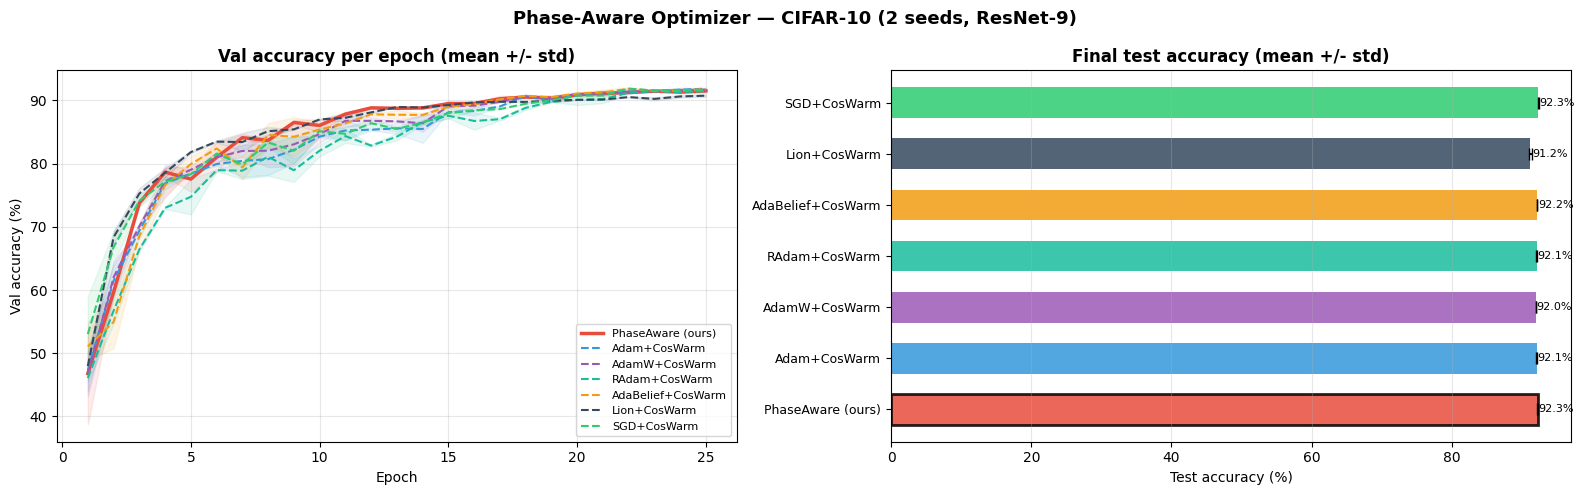

Fig 1 saved: accuracy curves + bar chart


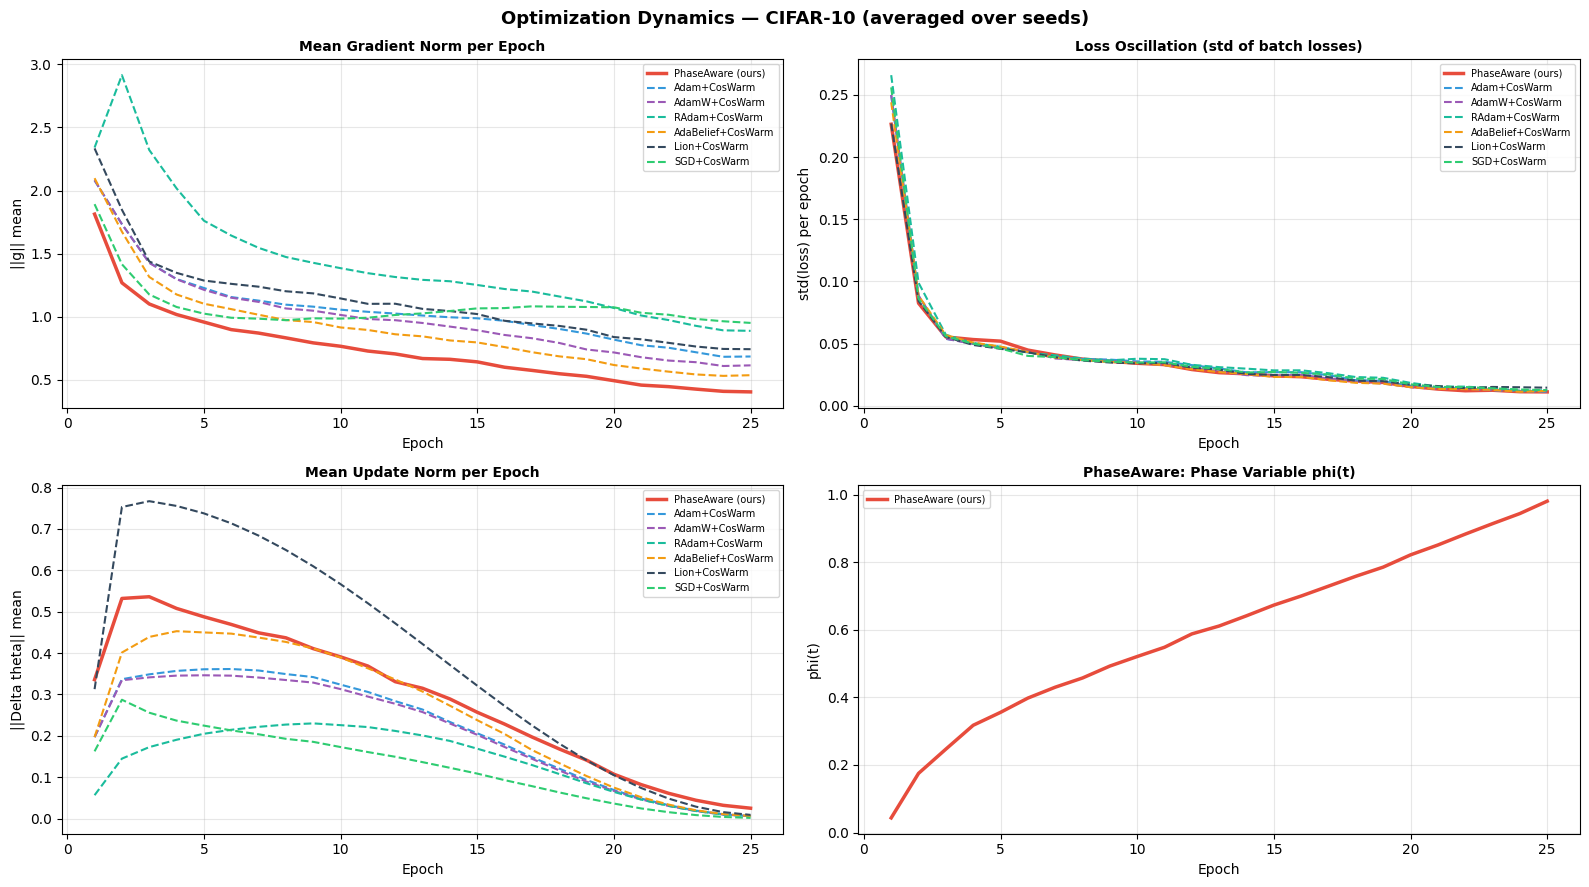

Fig 2 saved: grad norm / loss oscillation / update norm / phase


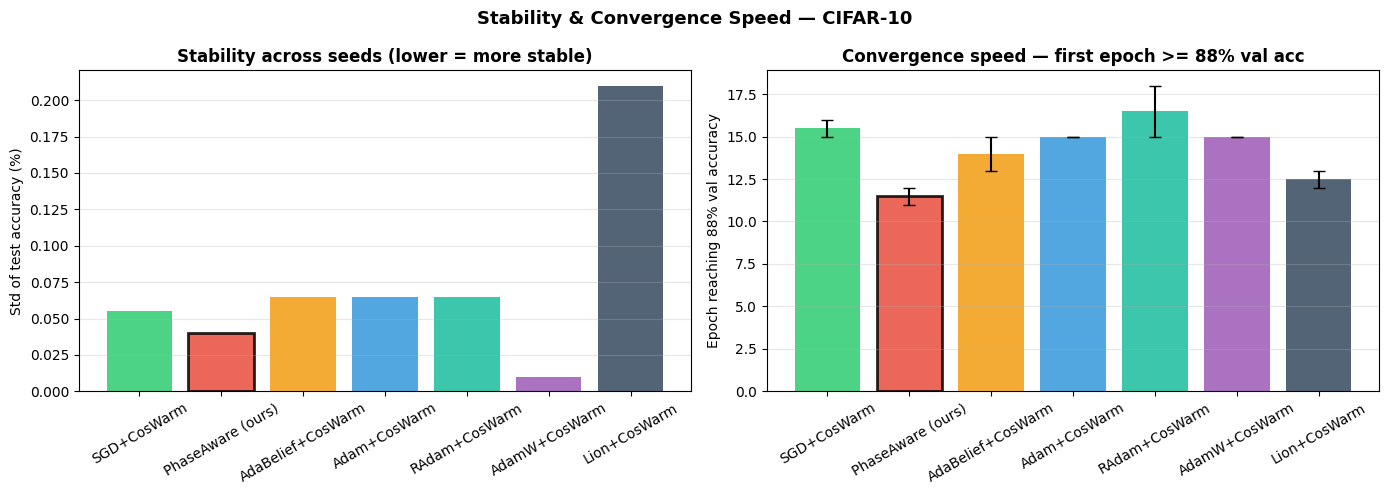

Fig 3 saved: stability (seed std) + convergence speed


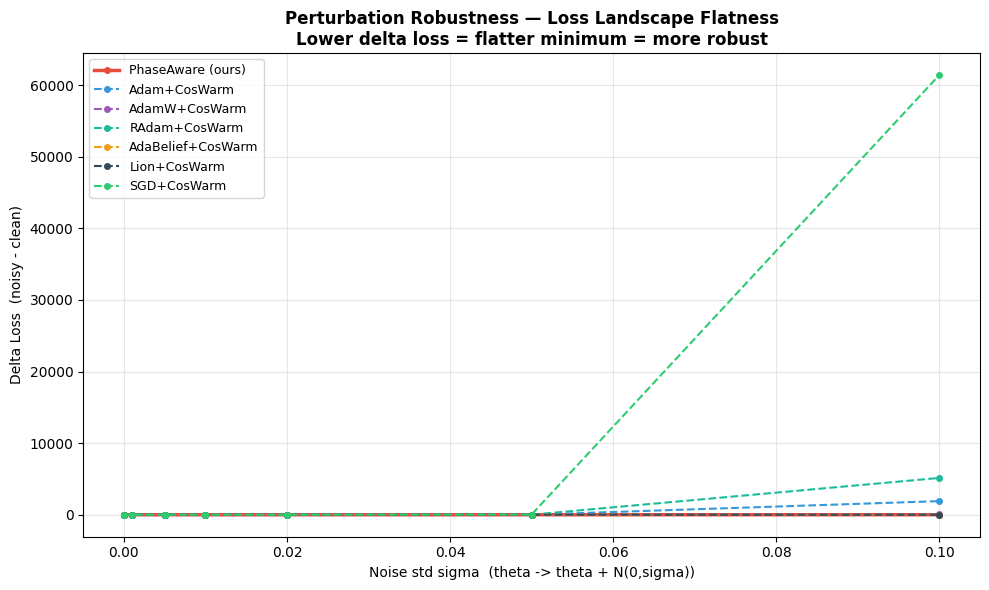

Fig 4 saved: perturbation robustness


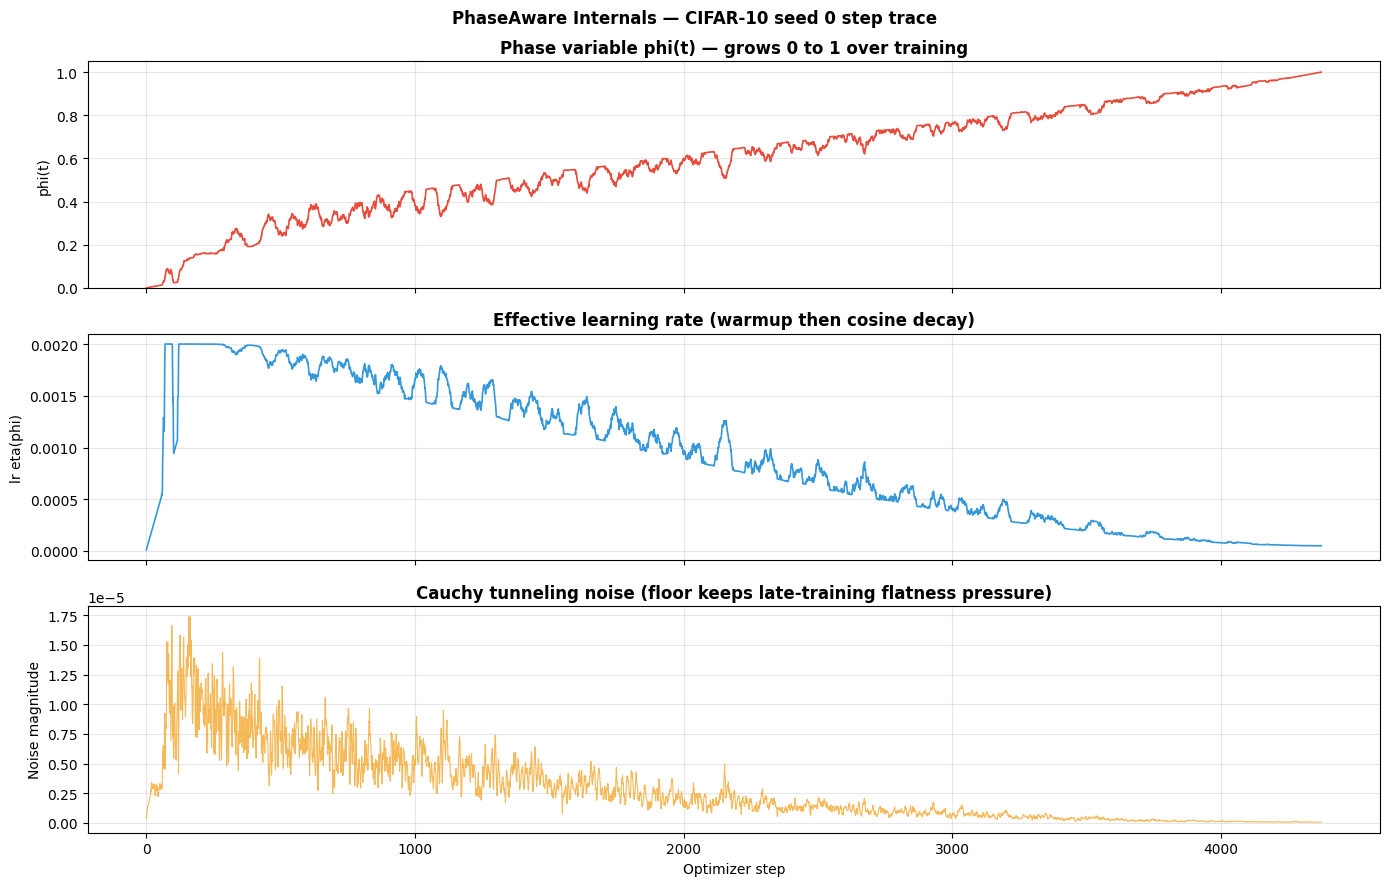

Fig 5 saved: PhaseAware phi / LR / noise step trace

All figures saved to /content/results_cifar10_20260605_213001/


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

OPT_COLORS = {
    "phase_aware": "#E74C3C", "adam": "#3498DB", "adamw": "#9B59B6",
    "radam": "#1ABC9C", "adabelief": "#F39C12",
    "lion": "#34495E", "sgd": "#2ECC71", "sam": "#E67E22",
}
OPT_LABELS = {
    "phase_aware": "PhaseAware (ours)", "adam": "Adam+CosWarm",
    "adamw": "AdamW+CosWarm", "radam": "RAdam+CosWarm",
    "adabelief": "AdaBelief+CosWarm",
    "lion": "Lion+CosWarm", "sgd": "SGD+CosWarm", "sam": "SAM+CosWarm",
}

def _c(n): return OPT_COLORS.get(n, "#888")
def _l(n): return OPT_LABELS.get(n, n)
def _lw(n): return 2.5 if n == "phase_aware" else 1.5
def _ls(n): return "-" if n == "phase_aware" else "--"


# ════════════════════════════════════════════════════════════════════════
# FIG 1 — Val accuracy curves + test accuracy bar chart
# ════════════════════════════════════════════════════════════════════════
fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(16, 5))
bar_means, bar_stds, bar_cols, bar_lbls = [], [], [], []

for name, runs in all_results.items():
    curves = np.array([r["history"]["val_accs"] for r in runs])
    mean, std = curves.mean(0), curves.std(0)
    x = np.arange(1, len(mean)+1)
    ax1a.plot(x, mean, color=_c(name), lw=_lw(name), ls=_ls(name), label=_l(name))
    ax1a.fill_between(x, mean-std, mean+std, color=_c(name), alpha=0.10)
    t_accs = [r["test_acc"] for r in runs]
    bar_means.append(np.mean(t_accs)); bar_stds.append(np.std(t_accs))
    bar_cols.append(_c(name)); bar_lbls.append(_l(name))

ax1a.set_title("Val accuracy per epoch (mean +/- std)", fontweight="bold")
ax1a.set_xlabel("Epoch"); ax1a.set_ylabel("Val accuracy (%)")
ax1a.legend(fontsize=8); ax1a.grid(True, alpha=0.3)

y_pos = np.arange(len(bar_lbls))
bars = ax1b.barh(y_pos, bar_means, xerr=bar_stds, color=bar_cols,
                 alpha=0.85, capsize=4, height=0.6)
for b, lbl in zip(bars, bar_lbls):
    if "PhaseAware" in lbl:
        b.set_edgecolor("black"); b.set_linewidth(2)
ax1b.set_yticks(y_pos); ax1b.set_yticklabels(bar_lbls, fontsize=9)
ax1b.set_xlabel("Test accuracy (%)")
ax1b.set_title("Final test accuracy (mean +/- std)", fontweight="bold")
ax1b.grid(True, axis="x", alpha=0.3)
for i, (m, s) in enumerate(zip(bar_means, bar_stds)):
    ax1b.text(m+s+0.05, i, f"{m:.1f}%", va="center", fontsize=8)

fig1.suptitle(f"Phase-Aware Optimizer — CIFAR-10 ({N_SEEDS} seeds, ResNet-9)",
              fontsize=13, fontweight="bold")
fig1.tight_layout()
plt.savefig(f"{out_dir}/fig1_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 1 saved: accuracy curves + bar chart")


# ════════════════════════════════════════════════════════════════════════
# FIG 2 — Optimization Dynamics (4 panels)
# ════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 9))
ax_gn, ax_lo, ax_un, ax_ph = axes2.flat

for name in all_results:
    ep = summary[name]["epoch_dynamics"]
    x  = np.arange(1, len(ep["grad_norm_mean"])+1)
    ax_gn.plot(x, ep["grad_norm_mean"],   color=_c(name), lw=_lw(name), ls=_ls(name), label=_l(name))
    ax_lo.plot(x, ep["loss_oscillation"], color=_c(name), lw=_lw(name), ls=_ls(name), label=_l(name))
    ax_un.plot(x, ep["update_norm_mean"], color=_c(name), lw=_lw(name), ls=_ls(name), label=_l(name))
    if name == "phase_aware":
        ph = ep.get("phase_mean", [])
        if ph:
            ax_ph.plot(np.arange(1, len(ph)+1), ph, color=_c(name), lw=2.5, label=_l(name))

for ax, title, ylabel in [
    (ax_gn, "Mean Gradient Norm per Epoch",           "||g|| mean"),
    (ax_lo, "Loss Oscillation (std of batch losses)", "std(loss) per epoch"),
    (ax_un, "Mean Update Norm per Epoch",             "||Delta theta|| mean"),
    (ax_ph, "PhaseAware: Phase Variable phi(t)",      "phi(t)"),
]:
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

fig2.suptitle("Optimization Dynamics — CIFAR-10 (averaged over seeds)",
              fontsize=13, fontweight="bold")
fig2.tight_layout()
plt.savefig(f"{out_dir}/fig2_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 2 saved: grad norm / loss oscillation / update norm / phase")


# ════════════════════════════════════════════════════════════════════════
# FIG 3 — Stability across seeds + Convergence speed
# ════════════════════════════════════════════════════════════════════════
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(14, 5))
names_s = sorted(summary, key=lambda n: -summary[n]["test_mean"])
stds_s  = [summary[n]["test_std"]     for n in names_s]
conv_m  = [summary[n]["conv_ep_mean"] for n in names_s]
conv_e  = [summary[n]["conv_ep_std"]  for n in names_s]
cols_s  = [_c(n) for n in names_s]
lbls_s  = [_l(n) for n in names_s]

bars3a = ax3a.bar(lbls_s, stds_s, color=cols_s, alpha=0.85)
for b, n in zip(bars3a, names_s):
    if n == "phase_aware": b.set_edgecolor("black"); b.set_linewidth(2)
ax3a.set_ylabel("Std of test accuracy (%)")
ax3a.set_title("Stability across seeds (lower = more stable)", fontweight="bold")
ax3a.tick_params(axis="x", rotation=30); ax3a.grid(True, axis="y", alpha=0.3)

bars3b = ax3b.bar(lbls_s, conv_m, yerr=conv_e, color=cols_s, alpha=0.85, capsize=4)
for b, n in zip(bars3b, names_s):
    if n == "phase_aware": b.set_edgecolor("black"); b.set_linewidth(2)
ax3b.set_ylabel("Epoch reaching 88% val accuracy")
ax3b.set_title("Convergence speed — first epoch >= 88% val acc",
               fontweight="bold")
ax3b.tick_params(axis="x", rotation=30); ax3b.grid(True, axis="y", alpha=0.3)

fig3.suptitle("Stability & Convergence Speed — CIFAR-10", fontsize=13, fontweight="bold")
fig3.tight_layout()
plt.savefig(f"{out_dir}/fig3_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 3 saved: stability (seed std) + convergence speed")


# ════════════════════════════════════════════════════════════════════════
# FIG 4 — Perturbation Robustness
# ════════════════════════════════════════════════════════════════════════
fig4, ax4 = plt.subplots(figsize=(10, 6))
for name, pres in perturb_results.items():
    sigmas = sorted(pres.keys())
    deltas = [pres[s] for s in sigmas]
    ax4.plot(sigmas, deltas, color=_c(name), lw=_lw(name), ls=_ls(name),
             marker="o", ms=4, label=_l(name))
ax4.set_xlabel("Noise std sigma  (theta -> theta + N(0,sigma))")
ax4.set_ylabel("Delta Loss  (noisy - clean)")
ax4.set_title("Perturbation Robustness — Loss Landscape Flatness\n"
              "Lower delta loss = flatter minimum = more robust",
              fontweight="bold")
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3)
fig4.tight_layout()
plt.savefig(f"{out_dir}/fig4_robustness.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 4 saved: perturbation robustness")


# ════════════════════════════════════════════════════════════════════════
# FIG 5 — PhaseAware internals (phi, LR, noise) — seed 0
# ════════════════════════════════════════════════════════════════════════
if "phase_aware" in all_results and all_results["phase_aware"]:
    pa_logger  = all_results["phase_aware"][0]["logger"]
    steps_data = pa_logger.steps
    if steps_data:
        fig5, axes5 = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
        ax5a, ax5b, ax5c = axes5
        xs = np.arange(len(steps_data))
        phases = [s["phase"]           for s in steps_data]
        lrs    = [s["lr"]              for s in steps_data]
        noises = [s["noise_magnitude"] for s in steps_data]
        ax5a.plot(xs, phases, color="#E74C3C", lw=1.2)
        ax5a.set_ylabel("phi(t)"); ax5a.set_ylim(0, 1.05)
        ax5a.set_title("Phase variable phi(t) — grows 0 to 1 over training",
                       fontweight="bold"); ax5a.grid(True, alpha=0.3)
        ax5b.plot(xs, lrs, color="#3498DB", lw=1.2)
        ax5b.set_ylabel("lr eta(phi)")
        ax5b.set_title("Effective learning rate (warmup then cosine decay)",
                       fontweight="bold"); ax5b.grid(True, alpha=0.3)
        ax5c.plot(xs, noises, color="#F39C12", lw=0.8, alpha=0.7)
        ax5c.set_ylabel("Noise magnitude")
        ax5c.set_xlabel("Optimizer step")
        ax5c.set_title("Cauchy tunneling noise (floor keeps late-training flatness pressure)",
                       fontweight="bold"); ax5c.grid(True, alpha=0.3)
        fig5.suptitle("PhaseAware Internals — CIFAR-10 seed 0 step trace",
                      fontsize=12, fontweight="bold")
        fig5.tight_layout()
        plt.savefig(f"{out_dir}/fig5_phaseaware_trace.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Fig 5 saved: PhaseAware phi / LR / noise step trace")

print(f"\nAll figures saved to {out_dir}/")

## Statistical Analysis — Welch's t-test + Full Dynamics Table

In [ ]:
from scipy import stats as scipy_stats

if "phase_aware" not in all_results:
    print("Run the experiment first.")
else:
    pa_test = np.array([r["test_acc"] for r in all_results["phase_aware"]])
    print(f"PhaseAware  test: mean={pa_test.mean():.3f}%  std={pa_test.std():.3f}%  n={len(pa_test)}")
    print()
    print(f"  {'Baseline':18}  {'Delta test':>10}  {'t-stat':>8}  {'p-value':>10}  {'sig':>5}  95% CI")
    print(f"  {'-'*76}")
    for name, runs in sorted(all_results.items(),
                             key=lambda x: -np.mean([r["test_acc"] for r in x[1]])):
        if name == "phase_aware": continue
        base  = np.array([r["test_acc"] for r in runs])
        t, p  = scipy_stats.ttest_ind(pa_test, base, equal_var=False)
        delta = pa_test.mean() - base.mean()
        se    = np.sqrt(pa_test.var(ddof=1)/len(pa_test) + base.var(ddof=1)/len(base))
        df_n  = se**4
        df_d  = ((pa_test.var(ddof=1)/len(pa_test))**2/(len(pa_test)-1) +
                 (base.var(ddof=1)/len(base))**2/(len(base)-1))
        ci    = scipy_stats.t.ppf(0.975, df_n/max(df_d, 1e-12)) * se
        sig   = "***" if p < 0.001 else ("** " if p < 0.01 else ("*  " if p < 0.05 else "ns "))
        print(f"  {name:18}  {delta:+9.3f}%  {t:8.3f}  {p:10.4f}  {sig:>5}  [{delta-ci:+.3f}, {delta+ci:+.3f}]")
    print()
    print("  *** p<0.001  ** p<0.01  * p<0.05  ns not significant")
    print("  Positive delta = PhaseAware beats the baseline")
    print("  NOTE: n=3 seeds — significance is indicative; use n>=5 for publication")

    # ── Full dynamics comparison table ──────────────────────────────────────
    print()
    print("=" * 108)
    print("FULL OPTIMIZER COMPARISON — accuracy + dynamics + landscape")
    print("=" * 108)
    hdr = (f"  {'Optimizer':18}  {'Test acc':>12}  {'Seed std':>9}  "
           f"{'Conv ep':>8}  {'Grad norm':>10}  {'Loss osc':>9}  "
           f"{'Upd norm':>9}  {'Perturb 0.01':>13}")
    print(hdr)
    print("  " + "-"*106)
    for name in sorted(summary, key=lambda n: -summary[n]["test_mean"]):
        s  = summary[name]
        ep = s["epoch_dynamics"]
        gn = float(np.mean(ep["grad_norm_mean"]))   if ep["grad_norm_mean"]   else float("nan")
        lo = float(np.mean(ep["loss_oscillation"])) if ep["loss_oscillation"] else float("nan")
        un = float(np.mean(ep["update_norm_mean"])) if ep["update_norm_mean"] else float("nan")
        pr = s["perturbation"].get("0.01", float("nan"))
        mrk = " <-- PhaseAware" if name == "phase_aware" else ""
        print(f"  {name:18}  "
              f"{s['test_mean']:6.2f}+/-{s['test_std']:.2f}%  "
              f"{s['test_std']:8.3f}%  "
              f"{s['conv_ep_mean']:7.1f}ep  "
              f"{gn:9.4f}  "
              f"{lo:8.4f}  "
              f"{un:8.4f}  "
              f"{pr:12.4f}{mrk}")
    print()
    print("  Seed std     = std of test accuracy across seeds (lower = more stable)")
    print("  Conv ep      = first epoch >= 88% val acc (lower = faster)")
    print("  Grad norm    = mean ||g|| across all steps")
    print("  Loss osc     = mean std of batch losses per epoch")
    print("  Upd norm     = mean ||Delta theta|| per step")
    print("  Perturb 0.01 = delta loss at sigma=0.01 weight noise (lower = flatter)")

PhaseAware  test: mean=92.260%  std=0.040%  n=2

  Baseline            Delta test    t-stat     p-value    sig  95% CI
  ----------------------------------------------------------------------------
  sgd                    -0.075%    -1.103      0.3942    ns   [-0.396, +0.246]
  adabelief              +0.105%     1.376      0.3251    ns   [-0.296, +0.506]
  adam                   +0.125%     1.638      0.2673    ns   [-0.276, +0.526]
  radam                  +0.155%     2.031      0.2046    ns   [-0.246, +0.556]
  adamw                  +0.290%     7.034      0.0725    ns   [-0.115, +0.695]
  lion                   +1.090%     5.099      0.1111    ns   [-1.229, +3.409]

  *** p<0.001  ** p<0.01  * p<0.05  ns not significant
  Positive delta = PhaseAware beats the baseline
  NOTE: n=3 seeds — significance is indicative; use n>=5 for publication

FULL OPTIMIZER COMPARISON — accuracy + dynamics + landscape
  Optimizer               Test acc   Seed std   Conv ep   Grad norm   Loss osc   Up